In [101]:
"""
Constructs the (unitary) DFT of the dihedral group in SageMath using knowledge of the representation theory.

""";

In [102]:
# ── Configuration ──────────────────────────────────────────────────────────────
n = 3; print("n =", n)
USE_FINITE_FIELD = True
p = 5; print("p =", p) # characteristic of the finite field
q = 5; print("q =", q) # size of the finite field

n = 3
p = 5
q = 5


In [103]:
# ── Build the coefficient ring and choose omega ─────────────────────────────────
if USE_FINITE_FIELD:
    # Find the smallest k such that n | (q^k - 1),
    # i.e. the multiplicative order of q mod n.
    k = Zmod(n)(q).multiplicative_order()
    F = GF(q**k, 'a')
    print(f"Working in GF({q}^{k}) = GF({q**k})")

    # Find a primitive n-th root of unity in F.
    # The multiplicative group of GF(q^k) is cyclic of order q^k - 1,
    # so a generator g satisfies g^((q^k-1)/n) has order n.
    g = F.multiplicative_generator()
    omega = g**((q**k - 1) // n)
    assert omega**n == F.one(), "omega is not an n-th root of unity"
    assert omega**(n-1) != F.one() or n == 1, "omega is not primitive"
    print(f"omega = {omega}  (order {omega.multiplicative_order()})")
else:
    K.<z> = CyclotomicField(n) #cyclotomic field containing a primitive n-th root of unity
    omega = z; print(f"omega = {omega}  (primitive n-th root of unity)")

Working in GF(5^2) = GF(25)
omega = 2*a + 1  (order 3)


In [104]:
G = DihedralGroup(n); print("G =", G) #D_n, dihedral group of order 2n
r = [g for g in G if g.order() == n][0] #rotation of order n, generator
s = [g for g in G if g.order() == 2 and g != r**(n//2)][0] #flip of order 2, generator
print("r =", r)
print("s =", s)

G = Dihedral group of order 6 as a permutation group
r = (1,3,2)
s = (2,3)


In [105]:
# returns (0, k) if g = r^k and (1, k) if g = s*r^k
def express_in_gens(g):
    for k in range(n):
        if g == r**k:
            return (0, k)
    for k in range(n):
        if g == s * r**k:
            return (1, k)

In [106]:
# n odd, we have two 1-dim'l irreps and (n-1)/2 2-dim'l irreps
# the 1-dim's irreps are trivial and sign
# the 2-dim'l irreps are given by rotation matrices and a flip matrix
def rho_odd(k, g, omega):
    (s_exp, r_exp) = express_in_gens(g)
    if k == 0:
        return matrix([1])
    if k == -1:
        if s_exp == 0:
            return matrix([1])
        if s_exp == 1:
            return matrix([-1])
    if k >= 1:
        if s_exp == 0:
            return matrix([[omega**(k*r_exp), 0], [0, omega**(-k*r_exp)]])
        if s_exp == 1:
            return matrix([[0, omega**(-k*r_exp)], [omega**(k*r_exp), 0]])

In [107]:
def dft_matrix_odd(omega,unitary=False):
    assert n % 2 == 1
    dim = lambda k: 1 if k in (-1, 0) else 2
    rows = []
    for g in G:
        if unitary:
            R.<x> = K[]
            k1.<a> = K.extension(x^2 - 2)
            L.<b> = k1.extension(x^2 - n)
            row = [(sqrt(L(dim(k)/(2*n)))*rho_odd(k, g, omega).change_ring(L)).list() for k in range(-1,(n-1)//2 + 1)]
        else:
            row = [rho_odd(k, g, omega).transpose().list() for k in range(-1,(n-1)//2 + 1)]
        rows.append(sum(row, []))
    return matrix(rows)

In [108]:
# for n even case
def rho_even(k, g, omega):
    (s_exp, r_exp) = express_in_gens(g)
    if k == 0:   # trivial
        return matrix([1])
    if k == -1:  # sign of rotation
        return matrix([(-1)**r_exp])
    if k == -2:  # sign of reflection
        return matrix([(-1)**s_exp])
    if k == -3:  # total sign
        return matrix([(-1)**(r_exp + s_exp)])
    if k >= 1:
        if s_exp == 0:
            return matrix([[omega**(k*r_exp), 0], [0, omega**(-k*r_exp)]])
        if s_exp == 1:
            return matrix([[0, omega**(-k*r_exp)], [omega**(k*r_exp), 0]])

In [109]:
# form the DFT matrix for n even
def dft_matrix_even(omega):
    assert n % 2 == 0
    rows = []
    for g in G:
        row = [rho_even(k, g, omega).list() for k in range(-3, n//2)]
        rows.append(sum(row, []))
    return matrix(rows)

In [110]:
# compute the trace of the DFT matrix using the formula for the entries
def matrix_entries(i, j):
    if j == 0:
        return 1 if i < n else -1
    if j == 1:
        return 1

    k = j - 2
    m = k // 4 + 1
    r = k % 4

    if i < n:
        return omega**(m * i) if r == 0 else omega**(-m * i) if r == 3 else 0
    else:
        return omega**(m * i) if r == 1 else omega**(-m * i) if r == 2 else 0

In [111]:
# compute the trace of the DFT matrix using the formula for the entries
def trace_dft():
    total = 2
    total += sum(omega**(((i-2)//4+1)*i) for i in range(2, n) if i % 4 == 2)
    total += sum(omega**(-((i-2)//4+1)*i) for i in range(2, n) if i % 4 == 1)
    total += sum(omega**(((i-2)//4+1)*i) for i in range(n, 2*n) if i % 4 == 3)
    total += sum(omega**(-(((i-2)//4+1)*i)) for i in range(n, 2*n) if i % 4 == 0)
    return total

In [112]:
def DFT_matrix_odd_from_entries():
    assert n % 2 == 1
    return matrix(2*n, 2*n, matrix_entries)

In [113]:
if not USE_FINITE_FIELD:
    uDFT = dft_matrix_odd(omega,unitary=True); uDFT.conjugate_transpose()*uDFT

In [114]:
DFT_matrix = dft_matrix_odd(omega) if n % 2 == 1 else dft_matrix_even(omega); print(DFT_matrix)

[      1       1       1       0       0       1]
[      1       1 2*a + 1       0       0 3*a + 3]
[      1       1 3*a + 3       0       0 2*a + 1]
[      4       1       0       1       1       0]
[      4       1       0 2*a + 1 3*a + 3       0]
[      4       1       0 3*a + 3 2*a + 1       0]


In [115]:
# the determinant is 2*n**n
if not USE_FINITE_FIELD:
    f = uDFT.charpoly(); print(f)
else:
    f = DFT_matrix.charpoly(); print(f)

x^6 + (4*a + 1)*x^5 + (3*a + 1)*x^4 + x^3 + (2*a + 2)*x^2 + (2*a + 2)*x + 1


In [116]:
if USE_FINITE_FIELD:
    L.<a> = f.splitting_field(); print(L)

Finite Field in a of size 5^12


In [117]:
if USE_FINITE_FIELD:
    R_L.<x> = PolynomialRing(L)
    f_L = R_L(f)
    f_L.factor()

In [118]:
if USE_FINITE_FIELD:
    eigenvalues = f.roots(L, multiplicities=False)
    print(eigenvalues)
    print(len(eigenvalues))

[2*a^11 + 4*a^10 + a^8 + 2*a^7 + 2*a^6 + 2*a^5 + a^4 + 3*a^3 + 2*a^2, a^11 + 3*a^10 + a^9 + 2*a^8 + 2*a^7 + 3*a^6 + a^5 + 4*a^4 + 3*a^2 + a + 4, 2*a^11 + a^10 + a^9 + 2*a^7 + 4*a^6 + 2*a^5 + 4*a^4 + a^2 + 3*a + 3, a^11 + a^9 + a^8 + 4*a^7 + 3*a^6 + 2*a^5 + 2*a^4 + 2*a^3 + a^2 + a + 3, a^11 + a^10 + a^9 + 2*a^8 + 2*a^6 + a^5 + 2*a^4 + 3*a^3 + 4*a^2 + 2*a + 1, 2*a^11 + 3*a^9 + 4*a^8 + 3*a^7 + a^5 + 3*a^2 + 2*a + 1]
6


In [119]:
def frobenius(x, p):
    return x**p

In [120]:
def frobenius_orbit(alpha, p):
    orbit = []
    seen = set()
    
    x = alpha
    while x not in seen:
        seen.add(x)
        orbit.append(x)
        x = x**p
    
    return orbit

In [121]:
def frobenius_orbits(eigenvalues, p):
    orbits = []
    seen = set()
    
    for lam in eigenvalues:
        if lam not in seen:
            orb = frobenius_orbit(lam, p)
            orbits.append(orb)
            seen.update(orb)
    
    return orbits

In [122]:
def discrete_log_Fq(x, alpha=None):
    F = x.parent()
    if x == 0:
        raise ValueError("Log undefined for 0")
    if alpha is None:
        alpha = F.multiplicative_generator()
    return x.log(alpha)

In [123]:
if USE_FINITE_FIELD:
    frobenius_orbits(eigenvalues, p)

In [124]:
if USE_FINITE_FIELD:
    len(frobenius_orbit(eigenvalues[0], p))

In [125]:
if USE_FINITE_FIELD:
    dlogs = [discrete_log_Fq(x, alpha=None) for x in eigenvalues]; dlogs

In [126]:
def brauer_map(x):
    if x == 0:
        return 0
    else:
        l = discrete_log_Fq(x, alpha=None)
        return exp(2 * pi * I * l / (L.order()-1))

In [127]:
if USE_FINITE_FIELD:
    complex_eigs = [brauer_map(eig) for eig in eigenvalues]; complex_eigs
    eigs_num = [complex(e.n(digits=30)) for e in complex_eigs]; eigs_num

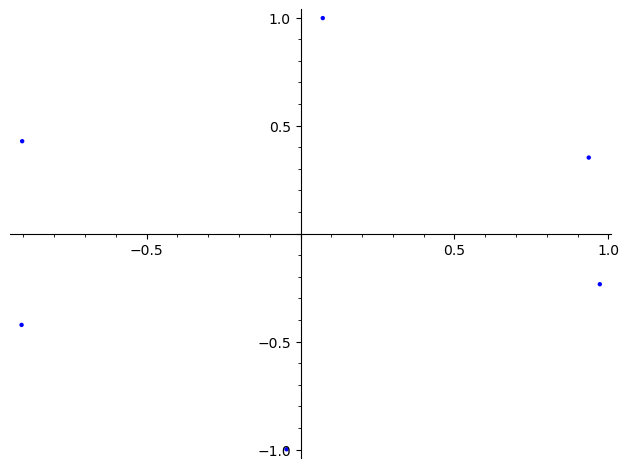

In [128]:
if USE_FINITE_FIELD:
    P = list_plot(
        [(z.real, z.imag) for z in eigs_num],
        plotjoined=False,
        marker='o'
    )

    P.show()

In [129]:
# form norm polynomial by acting on coefficients of characteristic polynomial by the Galois group
def norm_poly(f, n):

    def sigma(i):
        phi = K.hom([z**i])
        return f.map_coefficients(phi)
    
    units = [i for i in range(1, n) if gcd(i, n) == 1]  # (Z/nZ)^×
    result = prod(sigma(i) for i in units)
    return result.change_ring(QQ)

In [131]:
if not USE_FINITE_FIELD:
    Nf = norm_poly(f, n); Nf

In [132]:
if not USE_FINITE_FIELD:
    Nf.is_irreducible()

In [133]:
if not USE_FINITE_FIELD:
    Nf.factor()

In [134]:
if not USE_FINITE_FIELD:
    Nf.galois_group()

In [135]:
if not USE_FINITE_FIELD:
    galois_group = TransitiveGroup(12, 299)
    print(galois_group.order())
    print(galois_group.is_solvable())
    print(galois_group.is_primitive())
    print(galois_group.structure_description())